<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 210%;text-align: center;border-radius: 10px 70px">
     🛍️ Mall Shopper Segmentation - Clustering Analysis 🛒

</center></p></h1>

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">1️⃣ Step 1 | About Dataset </font><br>
 <br>   
<br>

<div style="border-radius: 5px;
            -webkit-border-radius: 5px;
            -moz-border-radius: 5px;
            font-family: cursive;
            border: 3px solid #008000;
            text-align: justify;
            color: black;
            font-size: 14px;
            padding: 10px;
            background:#F2FFFF">
    <p style="color: green; font-weight: bold; font-size: 16px;">About Dataset</p>
    <p>
        The dataset contains information about customers, focusing on their demographic attributes. 
        The features include customer ID, gender, age, annual income (in thousands of dollars), and 
        spending score (ranging from 1 to 100). This data is often used for market segmentation, 
        clustering, and customer behavior analysis.
    </p>
</div>

https://www.kaggle.com/datasets/kryusufkaya/mall-customers-dataset

<a class="anchor" id="setup"></a>
<br>
<br>
<br>
<font style="font-family:Gabriola; font-size:300%;">2️⃣ Step 2 |  Libraries </font><br>
 <br>   
<br>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.preprocessing import StandardScaler, RobustScaler,MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Data Loading  
</center></p></h1>

In [5]:
df=pd.read_excel(r'D:\Data Analysis- Scientist\Mchine Learning\ML-1\05.3.Mall_Customers.xlsx')

In [6]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<h1><p><center style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">
      Basic Understanding Data  
</center></p></h1>

###  Checking Dimensions of the Data.

In [7]:
df.shape

(200, 5)

In [8]:
# the number of rows and columns in train dataset 
rows , columns = df.shape 
print ("The number of rows in train dataset : " , rows)
print ("The number of columns in train dataset : " , columns)

The number of rows in train dataset :  200
The number of columns in train dataset :  5


<p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold">
<div style="border-radius: 5px;
           -webkit-border-radius: 5px;
           -moz-border-radius: 5px;
           font-family: cursive;
           border: 3px solidrgb(0, 90, 128);
           text-align: justify;
           color: black;
           font-size: 14px;
           padding: 5px;
           background:#F2FFFF"><span>Obervation :</span><br>
    <ul>
        <li>This dataset includes the details of <b>200/b> samples</li>
        <li>The number of features for the dataframe is equal to <b>5</b></li>
    </ul></div>

###  Checking the basic information of dataset.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


###  Checking NaN values in our Dataset.

In [10]:
df.isnull().sum().to_frame().rename(columns={0:"Total No. of Missing Values"})

,Total No. of Missing Values
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [11]:
print("Duplicate Values =",df.duplicated().sum())

Duplicate Values = 0


<p style="text-align: justify; font-family: cursive; font-size: 14px; color : green ; font-weight : bold">
<div style="border-radius: 5px;
           -webkit-border-radius: 5px;
           -moz-border-radius: 5px;
           font-family: cursive;
           border: 3px solidrgb(0, 90, 128);
           text-align: justify;
           color: black;
           font-size: 14px;
           padding: 5px;
           background:#F2FFFF"><span>Obervation :</span><br>
    <ul>
        <li>From the above output we can say that there is <b>0</b> </li>
    </ul></div>

###  Showing Only Categorical & Numerical Features.

In [12]:
df.dtypes 

CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

In [13]:
df.select_dtypes(exclude="object").head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,2,21,15,81
2,3,20,16,6
3,4,23,16,77
4,5,31,17,40


In [14]:
df.dtypes[df.dtypes == 'object']

Genre    object
dtype: object

<h1 id ="import_lib" ></a> Descriptive Statistics Analysis</h1>

In [15]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     <p style="font-weight: bold; color:rgb(20, 1, 1);">
     Since the means are larger than the standard deviations, there is likely no significant risk of outliers.
     </p>
</div>

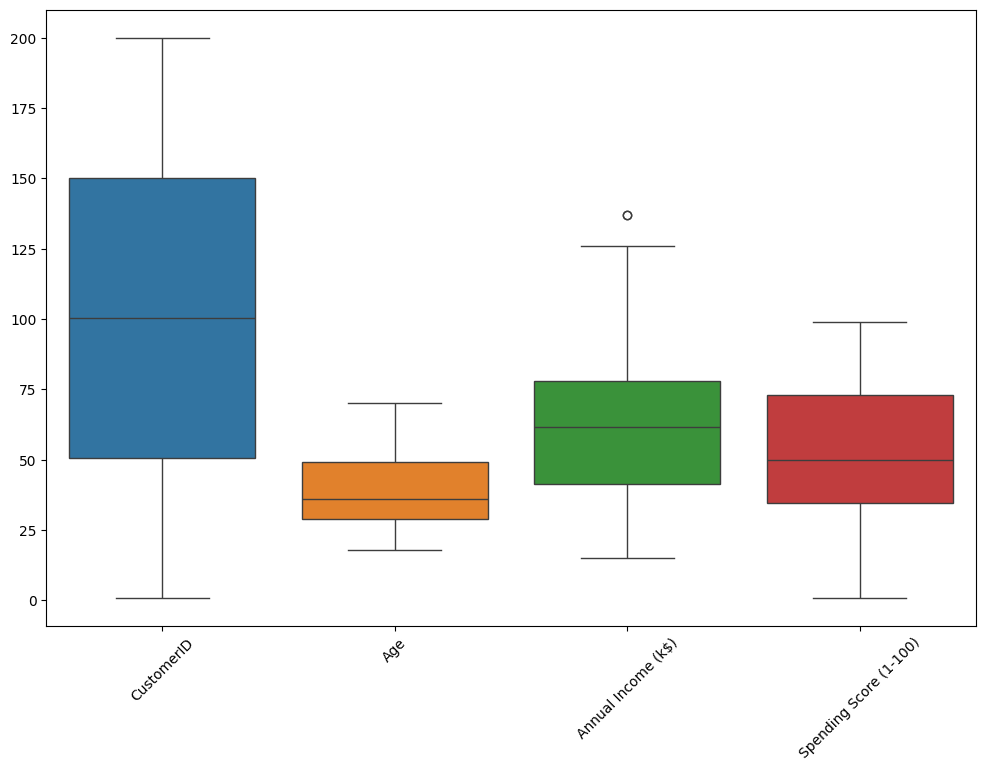

In [16]:
plt.figure(figsize=(12,8))
sns.boxplot(df )
plt.xticks(rotation=45)
plt.show()

In [7]:
df.rename(columns = { "Genre":"Gender",  "Annual Income (k$)": "income",
                       "Spending Score (1-100)":"score"}, inplace = True)

In [34]:
df.head()

,customer_id,Gender,age,income,score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [35]:
df[df["income"] == 137]

,customer_id,Gender,age,income,score
198,199,Male,32,137,18
199,200,Male,30,137,83


In [36]:
df[df["Gender"] == "Male"].median(numeric_only=True)

customer_id    106.5
age             37.0
income          62.5
score           50.0
dtype: float64

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     
<p style="font-weight: bold; color:rgb(1, 17, 8);">Individuals with an income of 137 are predominantly male.</p>
     
<p style="font-weight: bold; color:rgb(0, 5, 2);">
         Furthermore, their incomes are generally above the overall average. Among male customers specifically, these incomes are significantly higher.
     </p>
</div>

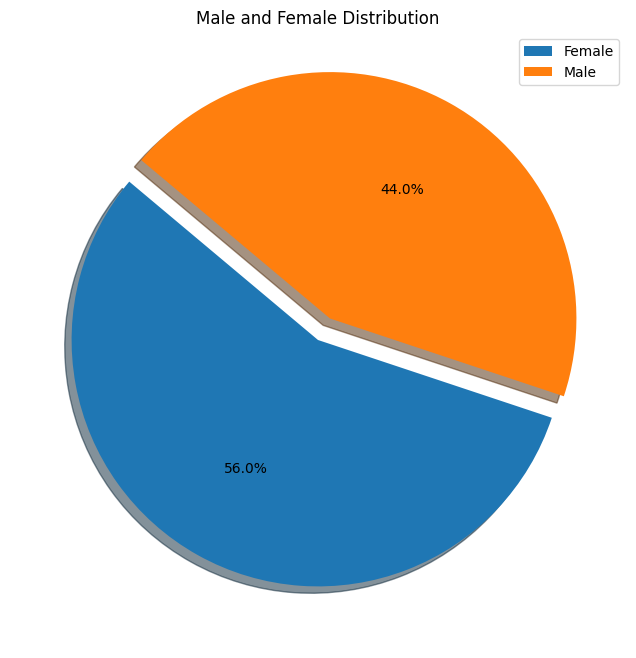

In [37]:
plt.figure(figsize=(8, 8))

explode = [0, 0.1]
plt.pie(df['Gender'].value_counts(),
        explode=explode,
        autopct='%1.1f%%',
        shadow=True,
        startangle=140)
plt.legend(labels=['Female', 'Male'])
plt.title('Male and Female Distribution')
plt.axis('off')
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     
<p style="font-weight: bold; color:rgb(1, 17, 8);">It has been observed that there are slightly more females than males in the dataset.</p>
</div>


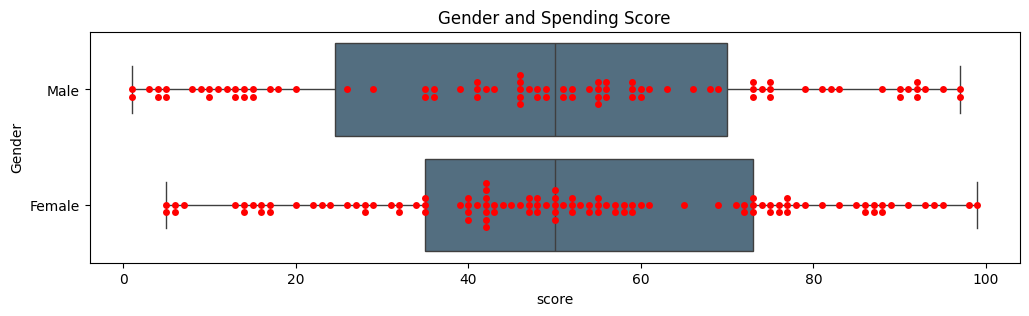

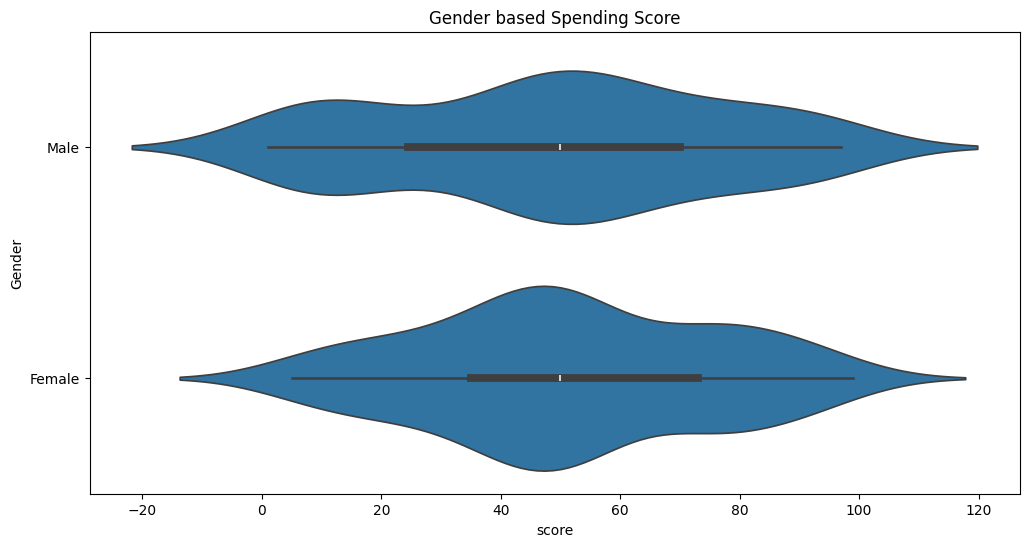

In [40]:
plt.figure(figsize=(12, 3))
sns.swarmplot(x='score', y='Gender', data=df, color="r")
sns.boxplot(x='score', y='Gender', data=df, saturation=.3)
plt.title('Gender and Spending Score')
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(x='score', y='Gender', data=df)
plt.title('Gender based Spending Score')
plt.show()

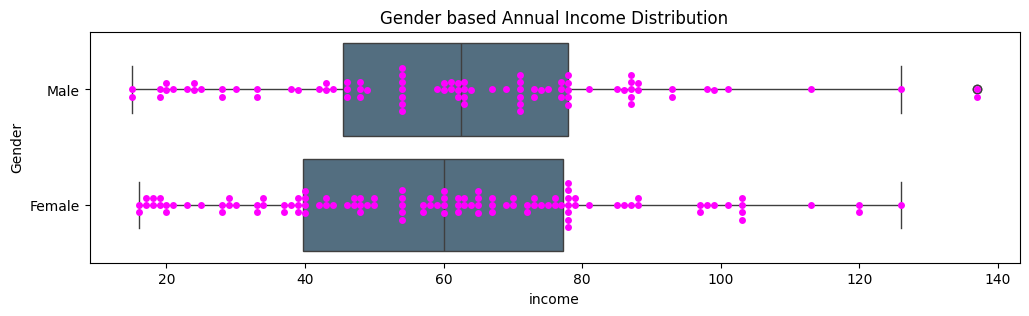

In [42]:
plt.figure(figsize=(12, 3))
sns.swarmplot(x='income', y='Gender', data=df, color="magenta")
sns.boxplot(x='income', y='Gender', data=df, saturation=0.3)
plt.title('Gender based Annual Income Distribution')
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     
<p style="font-weight: bold; color:rgb(1, 17, 8);">When examining spending scores based on gender, it is evident that there is significant overlap in many areas, with some instances where females exhibit high scores.</p>
</div>

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">  pairplot is a useful tool for visualizing & potential correlations between all features.</p>
</div>

c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1513: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  func(x=vector, **plot_kwargs)
c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\axisgrid.py:1615: UserWarning: Ignoring `palette` because no `hue` variable has been assigne

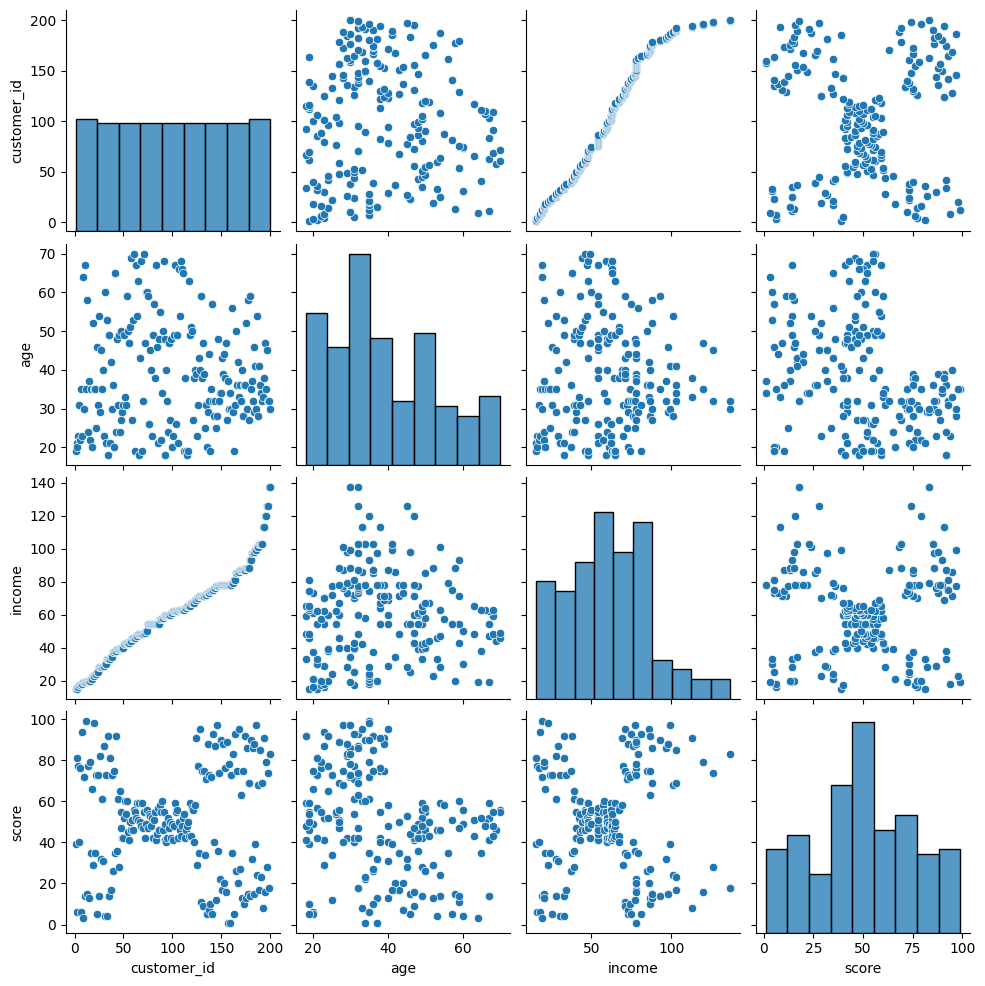

In [45]:
sns.pairplot(df, palette="bright" )
plt.show()

In [44]:
for col in df.select_dtypes(include=["number"]).columns:
    skewness = df[col].skew()
    kurtosis = df[col].kurt()
    print(f"{col} - Skewness: {skewness:.2f}, Kurtosis: {kurtosis:.2f}")

customer_id - Skewness: 0.00, Kurtosis: -1.20
age - Skewness: 0.49, Kurtosis: -0.67
income - Skewness: 0.32, Kurtosis: -0.10
score - Skewness: -0.05, Kurtosis: -0.83


<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> ✨ Correlation between independent variable and dependent variable ✨</p>

<Axes: >

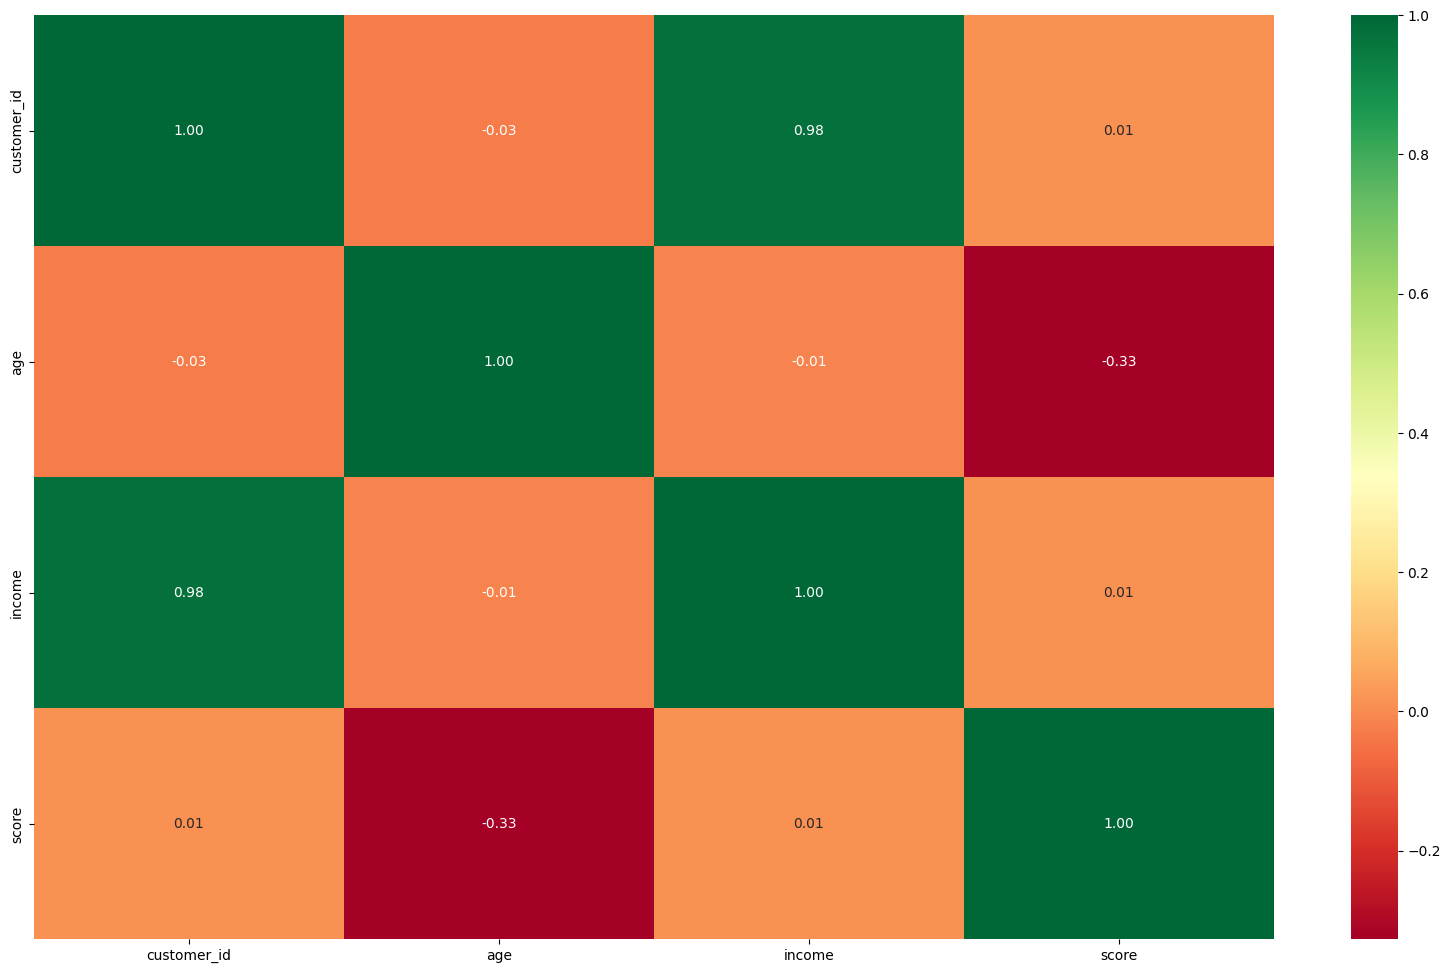

In [48]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(20,12))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn')

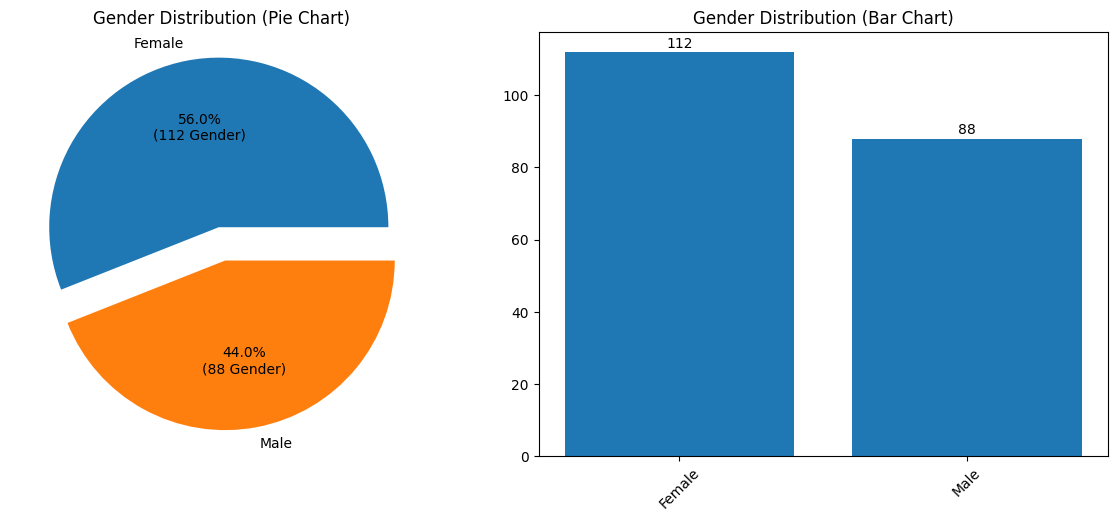

In [49]:
def H_prediction(feature):
    """Visualize distribution of a categorical feature using pie and bar charts"""
    
    # Get value counts for the specified feature
    value_counts = dict(df[feature].value_counts())
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Pie chart
    explode = [0.1] * len(value_counts)  # Explode all slices
    axes[0].pie(value_counts.values(), labels=value_counts.keys(),
                autopct=lambda p: f'{p:.1f}%\n({p*sum(value_counts.values())/100:.0f} Gender)',
                explode=explode)
    axes[0].set_title(f"{feature} Distribution (Pie Chart)")
    
    # Bar chart
    axes[1].bar(value_counts.keys(), value_counts.values())
    for i, count in enumerate(value_counts.values()):
        axes[1].text(i, count+0.5, str(count), ha='center', va='bottom')
    axes[1].set_title(f"{feature} Distribution (Bar Chart)")
    
    plt.tight_layout()
    plt.xticks(rotation=45)
    plt.show()

# Example usage with your 'fueltype' column
H_prediction('Gender')  # Pass column name as string

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">Remove Outliers</p>
</div>

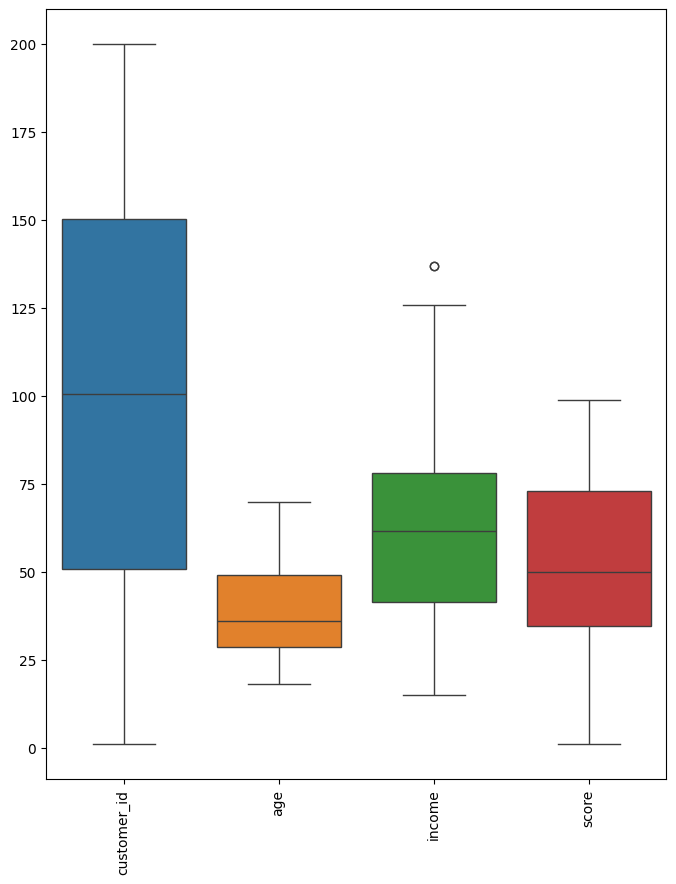

In [50]:
plt.figure(figsize=(8, 10))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px"> Missing Data</p>
</div>

## Missing data

In [51]:
df.isnull().sum()

customer_id    0
Gender         0
age            0
income         0
score          0
dtype: int64

In [52]:
# Detection missing values
print(f"The number of missing values in dataset : \n{df.isnull().sum()} " )

The number of missing values in dataset : 
customer_id    0
Gender         0
age            0
income         0
score          0
dtype: int64 


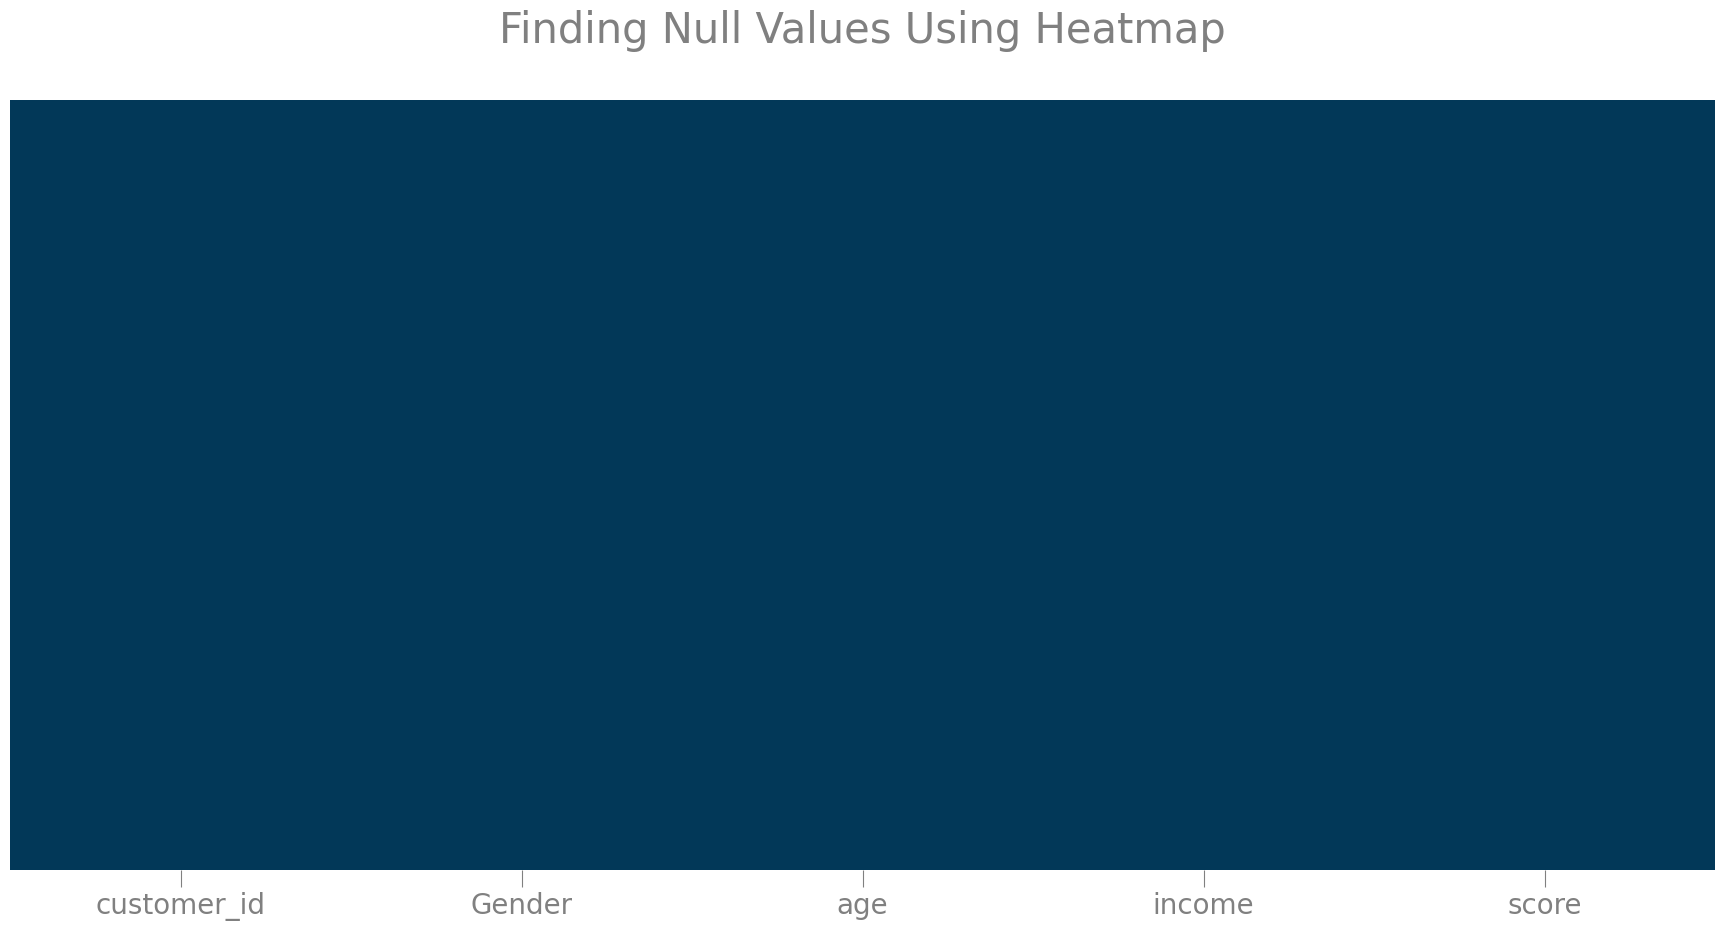

In [53]:
plt.figure(figsize=(22,10))
plt.xticks(size=20,color='grey')
plt.tick_params(size=12,color='grey')
plt.title('Finding Null Values Using Heatmap\n',color='grey',size=30)
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=False,
            cmap='PuBu_r',
            )
plt.show()

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">Create a model</p>
</div>

![unsupervised](https://databasetown.com/wp-content/uploads/2023/05/Unsupervised-Learning.jpg)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fdatabasetown.com%2Funsupervised-learning-types-applications%2F&psig=AOvVaw3OLEBemfakkkUbjtWyb8lc&ust=1700405736787000&source=images&cd=vfe&opi=89978449&ved=0CBQQjhxqFwoTCLiw_5HnzYIDFQAAAAAdAAAAABAD)

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">✨ K-Means Clustering ✨</p>
</div>

![kmeans](https://editor.analyticsvidhya.com/uploads/56854k%20means%20clustering.png)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.analyticsvidhya.com%2Fblog%2F2020%2F10%2Fa-simple-explanation-of-k-means-clustering%2F&psig=AOvVaw3cw8LOufDptpormaHu5Bcf&ust=1700398969640000&source=images&cd=vfe&opi=89978449&ved=0CBQQjhxqFwoTCMiF9P7NzYIDFQAAAAAdAAAAABAD)

In [8]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'income', 'score'], dtype='object')

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">✨ Hopkins Test ✨</p>
</div>

![hopkins](https://i.ytimg.com/vi/E2VAV9eUh1o/maxresdefault.jpg)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.youtube.com%2Fwatch%3Fv%3DE2VAV9eUh1o&psig=AOvVaw1dz6u4Y1-sliRNvZ5Z9V58&ust=1700399141138000&source=images&cd=vfe&opi=89978449&ved=0CBQQjhxqFwoTCLiHk83OzYIDFQAAAAAdAAAAABAD)
hopkins : A statistical method that measures data clustering tendency.
More than 0.5 is prone to clustering.

In [55]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from random import sample
from numpy.random import uniform



# Select relevant features
X = df[['income', 'score']]

def hopkins(X, sampling_size=0.3):
    """Calculate Hopkins statistic for cluster tendency"""
    X = StandardScaler().fit_transform(X.values) if hasattr(X, 'values') else StandardScaler().fit_transform(X)
    n = X.shape[0]
    d = X.shape[1]
    m = int(sampling_size * n)
    
    # Uniform random samples
    uniform_samples = uniform(np.min(X, axis=0), np.max(X, axis=0), (m, d))
    
    # Random existing samples
    random_indices = sample(range(n), m)
    data_samples = X[random_indices]
    
    # Fit nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=2).fit(X)  # n_neighbors=2 to skip self
    
    # Distances for uniform samples
    u_distances, _ = nbrs.kneighbors(uniform_samples, n_neighbors=1)
    
    # Distances for data samples (skip self)
    w_distances, _ = nbrs.kneighbors(data_samples, n_neighbors=2)
    w_distances = w_distances[:, 1]  # distance to nearest neighbor
    
    H = np.sum(u_distances) / (np.sum(u_distances) + np.sum(w_distances))
    return H

# Calculate Hopkins statistic
hopkins_stat = hopkins(X)
print(f"Hopkins Statistic: {hopkins_stat:.3f}")

Hopkins Statistic: 0.702


<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">✨ Choosing The Optimal Number of Clusters ✨</p>
</div>

### ✨ Elbow Method ✨

![elbow](https://miro.medium.com/v2/resize:fit:1340/1*RnvrdhlUxHWss3vOffHT5g.png)
[Credit](https://www.google.com/url?sa=i&url=https%3A%2F%2Fmedium.com%2Fmlearning-ai%2Felbow-method-vs-silhouette-co-efficient-in-determining-the-number-of-clusters-33baff2fbeee&psig=AOvVaw13SYCkS-Yd2NZS_TZHA0B1&ust=1700399312464000&source=images&cd=vfe&opi=89978449&ved=0CBMQjhxqFwoTCLjasZvPzYIDFQAAAAAdAAAAABAI)

In [10]:
# Data preprocessing
# Select features for clustering (Age, Annual Income, Spending Score)
X = df[['Age', 'income', 'score']]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\skle

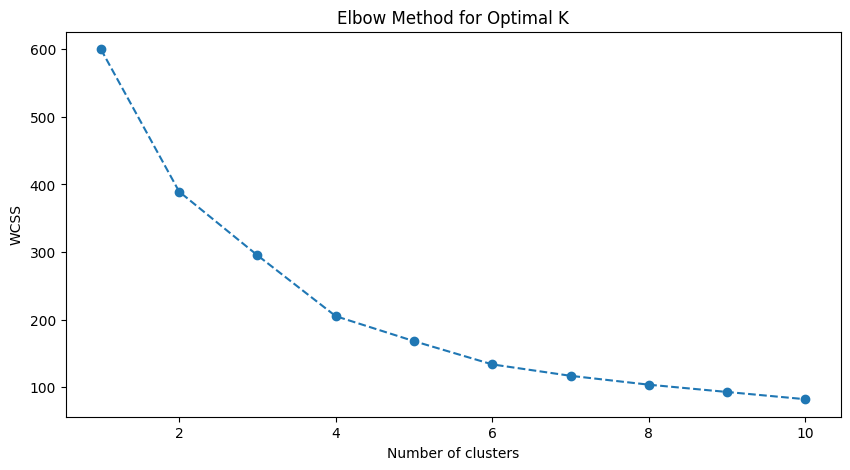

In [11]:
# K-Means Clustering
# Determine optimal number of clusters using Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     
<p style="font-weight: bold; color: black;">An elbow is observed at 4 and 7, indicating a point of inflection. According to the elbow graph, selecting a higher number of clusters increases complexity. Therefore, it is more suitable to choose 4 clusters in this case.</p>
</div>

In [12]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [13]:
centroids = kmeans.cluster_centers_    #این نقاط، میانگین تمام داده‌های هر خوشه هستند
labels = kmeans.labels_

print("centroids:",centroids)
print("Inertia:", kmeans.inertia_)

centroids: [[ 0.5310735  -1.2905084  -1.23646671]
 [-0.98067852 -0.74305983  0.46744035]
 [-0.42880597  0.97484722  1.21608539]
 [ 0.07333084  0.97494509 -1.19729675]
 [ 1.20484056 -0.23577338 -0.05236781]]
Inertia: 168.24758017556834


<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">✨ Silhouette Analysis ✨</p>
</div>

In [14]:

score = silhouette_score(X, kmeans.labels_)
print("Silhouette Score:", score)

Silhouette Score: 0.41618308781722624


In [15]:
range_n_clusters = range(2,9)
for num_clusters in range_n_clusters:
    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters,
                    random_state=42)
    kmeans.fit(X)
    cluster_labels = kmeans.labels_
    # silhouette score
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(f"For n_clusters={num_clusters}, the silhouette score is {silhouette_avg}")

c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\

For n_clusters=2, the silhouette score is 0.293166070535953
For n_clusters=3, the silhouette score is 0.3839349967742105
For n_clusters=4, the silhouette score is 0.40546302077733304
For n_clusters=5, the silhouette score is 0.44428597560893024
For n_clusters=6, the silhouette score is 0.4523443947724053
For n_clusters=7, the silhouette score is 0.43883522027400007
For n_clusters=8, the silhouette score is 0.43280878015743623


c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     <p style="font-weight: bold; color: black;">While examining silhouette scores, it is noted that the scores are relatively close to each other. However, when considered in conjunction with the elbow method, a cluster count of 4 appears to be suitable. It's worth mentioning that the silhouette score considers both intra-cluster and inter-cluster distances, aiming for a value close to 1 for better clustering results.</p>
</div>


c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


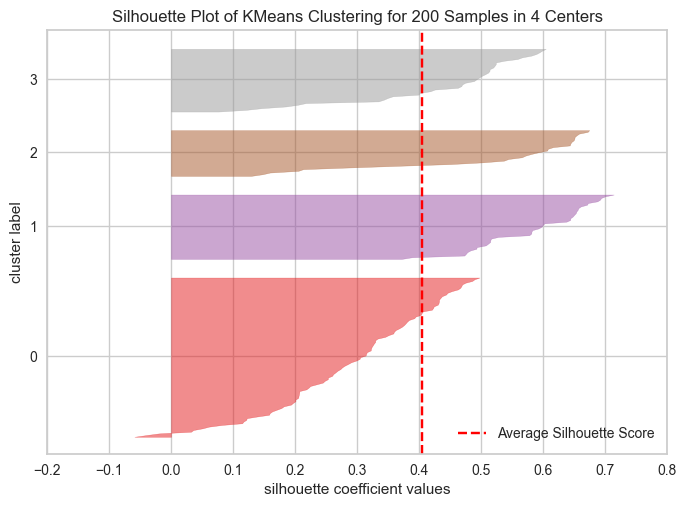

Indices with negative Silhouette scores: [ 4 52 84]


In [16]:
from yellowbrick.cluster import SilhouetteVisualizer

model = KMeans(n_clusters=4,
                random_state=42)          # we decided n_clusters=3!
visualizer = SilhouetteVisualizer(model)

visualizer.fit(X)    # Fit the data to the visualizer
visualizer.poof()

silhouette_scores = visualizer.silhouette_samples_

negative_silhouette_indices = np.where(silhouette_scores < 0)[0]

print("Indices with negative Silhouette scores:", negative_silhouette_indices)

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     <p style="font-weight: bold; color: black;">While examining silhouette scores, it is noted that the scores are relatively close to each other. However, when considered in conjunction with the elbow method, a cluster count of 4 appears to be suitable. It's worth mentioning that the silhouette score considers both intra-cluster and inter-cluster distances, aiming for a value close to 1 for better clustering results.</p>
</div>

In [17]:
# Add cluster labels to the dataframe
df['KMeans_Cluster'] = kmeans_labels

In [19]:
df.head()

,CustomerID,Gender,Age,income,score,KMeans_Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">✨Visualizing and Labeling All the Clusters ✨</p>
</div>

In [20]:
df['KMeans_Cluster'].value_counts()

KMeans_Cluster
1    54
4    47
2    40
3    39
0    20
Name: count, dtype: int64

In [24]:
import plotly.express as px

fig = px.scatter_3d(df,
                   x='score',
                   y='income',
                   z='Age',
                   color='KMeans_Cluster',
                   labels={
                       'score': 'Spending Score',
                       'income': 'Annual Income',
                       'Age': 'Age',
                       'KMeans_Cluster': 'Cluster'
                   },
                   hover_data=['Gender', 'CustomerID'],
                   title='Customer Segmentation by Spending, Income and Age')

fig.update_traces(marker=dict(size=5, opacity=0.8))

fig.update_layout(
    scene=dict(
        xaxis_title='Spending Score',
        yaxis_title='Annual Income',
        zaxis_title='Age'
    ),
    margin=dict(l=0, r=0, b=0, t=30)
)


<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
     <p style="font-weight: bold; color: black;">When examined in three dimensions, data points become more distinguishable according to clusters.</p>
</div>


Text(0.5, 1.0, 'Distribution of clusters')

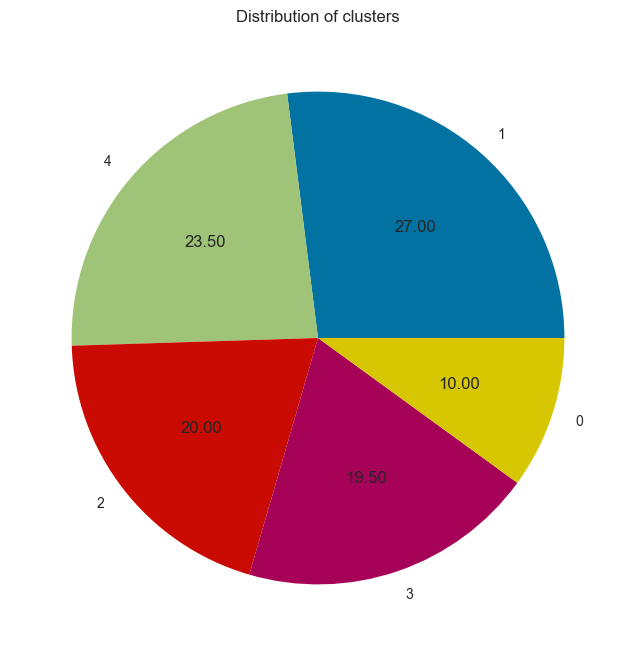

In [26]:
df['KMeans_Cluster'].value_counts().plot(kind="pie", autopct='%.2f', figsize=[8,8], label="")
plt.title('Distribution of clusters')

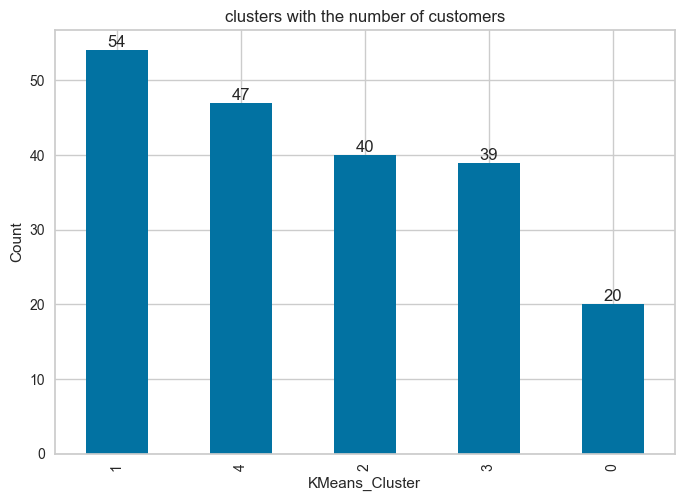

In [40]:
plt.title("clusters with the number of customers")
plt.xlabel("clusters")
plt.ylabel("Count")
ax = df['KMeans_Cluster'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0])
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    <ul style="font-weight: bold; color: black; margin: 0; padding-left: 20px;">
        <li>It is observed that the highest number of individuals is in Cluster 1, while the lowest number is in Cluster 2.</li>
    </ul>
</div>

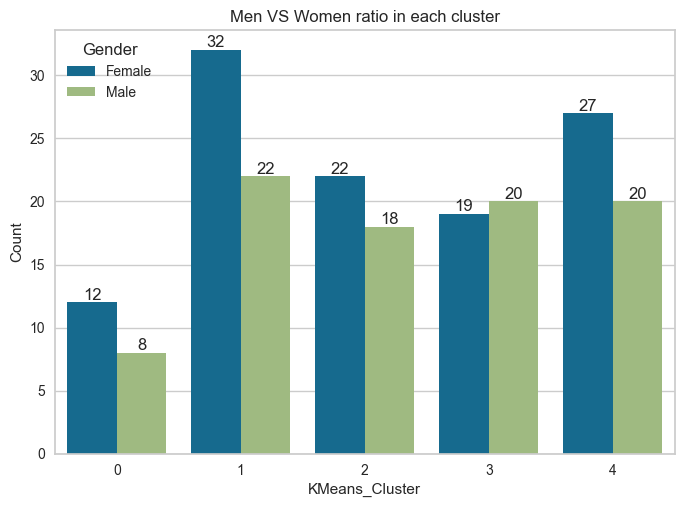

In [41]:
plt.title("Men VS Women ratio in each cluster")
plt.ylabel("Count")
ax = sns.countplot(x=df['KMeans_Cluster'], hue=df['Gender'])
for p in ax.containers:
    ax.bar_label(p)
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    <ul style="font-weight: bold; color: black; margin: 0; padding-left: 20px;">
        <li>Except for Cluster 1, the number of females is higher than males in the other clusters</li>
    </ul>
</div>

In [42]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'income', 'score', 'KMeans_Cluster',
       'DBSCAN_Cluster'],
      dtype='object')

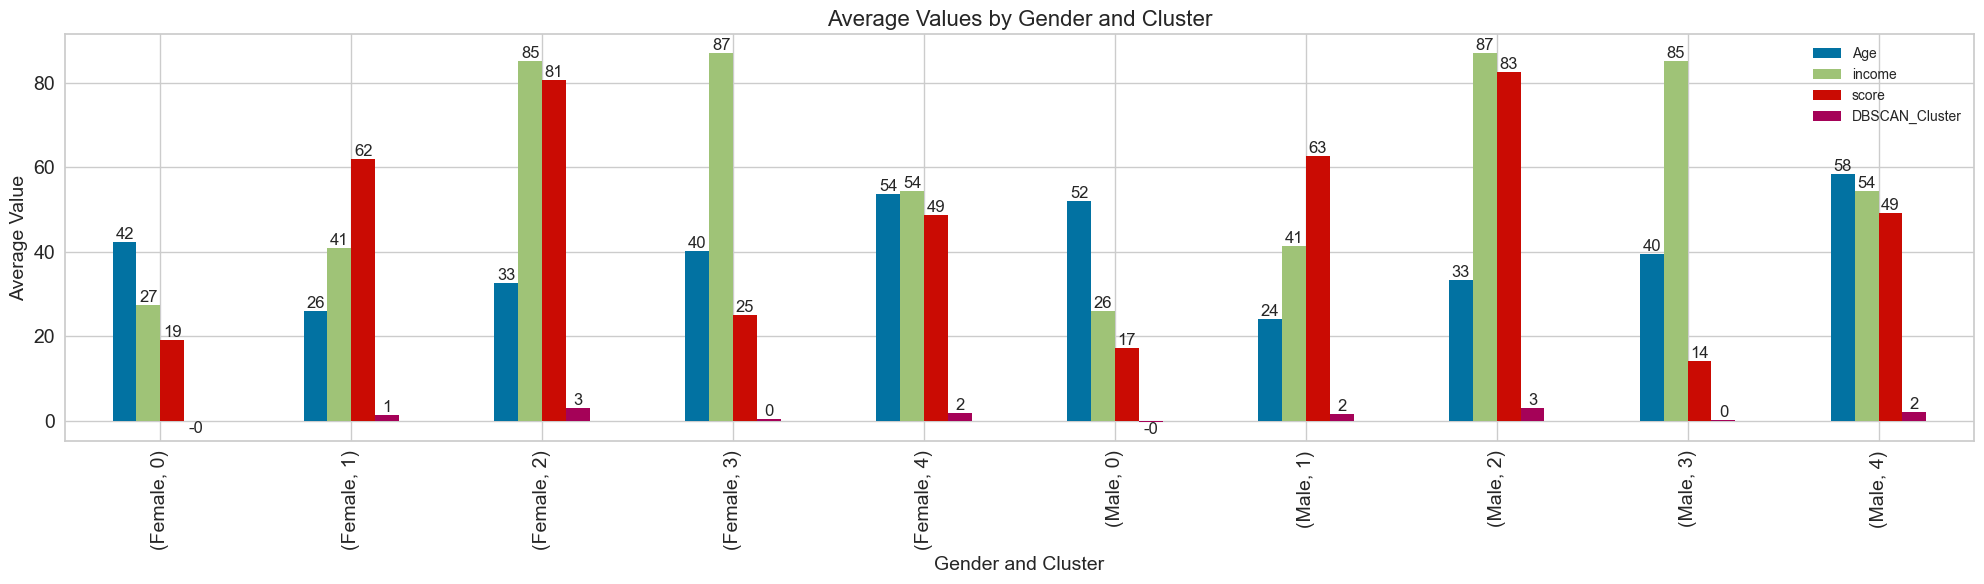

In [45]:

# Drop 'CustomerID' column and group by Gender and Cluster, then take the mean
grouped_df = df.drop("CustomerID", axis=1).groupby(["Gender", "KMeans_Cluster"]).mean()

# Plotting
ax = grouped_df.plot(kind="bar", figsize=(20, 6), fontsize=14)

# Add bar labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=12)

plt.title("Average Values by Gender and Cluster", fontsize=16)
plt.ylabel("Average Value", fontsize=14)
plt.xlabel("Gender and Cluster", fontsize=14)
plt.tight_layout()
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    <ul style="font-weight: bold; color: black; margin: 0; padding-left: 20px;">
        <li>EWhen comparing the graphs of men and women, it is observed that the scores of men and women in each cluster are similar</li>
    </ul>
</div>

In [28]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'income', 'score', 'KMeans_Cluster'], dtype='object')

C:\Users\Amir\AppData\Local\Temp\ipykernel_15980\3780956623.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Amir\AppData\Local\Temp\ipykernel_15980\3780956623.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


C:\Users\Amir\AppData\Local\Temp\ipykernel_15980\3780956623.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




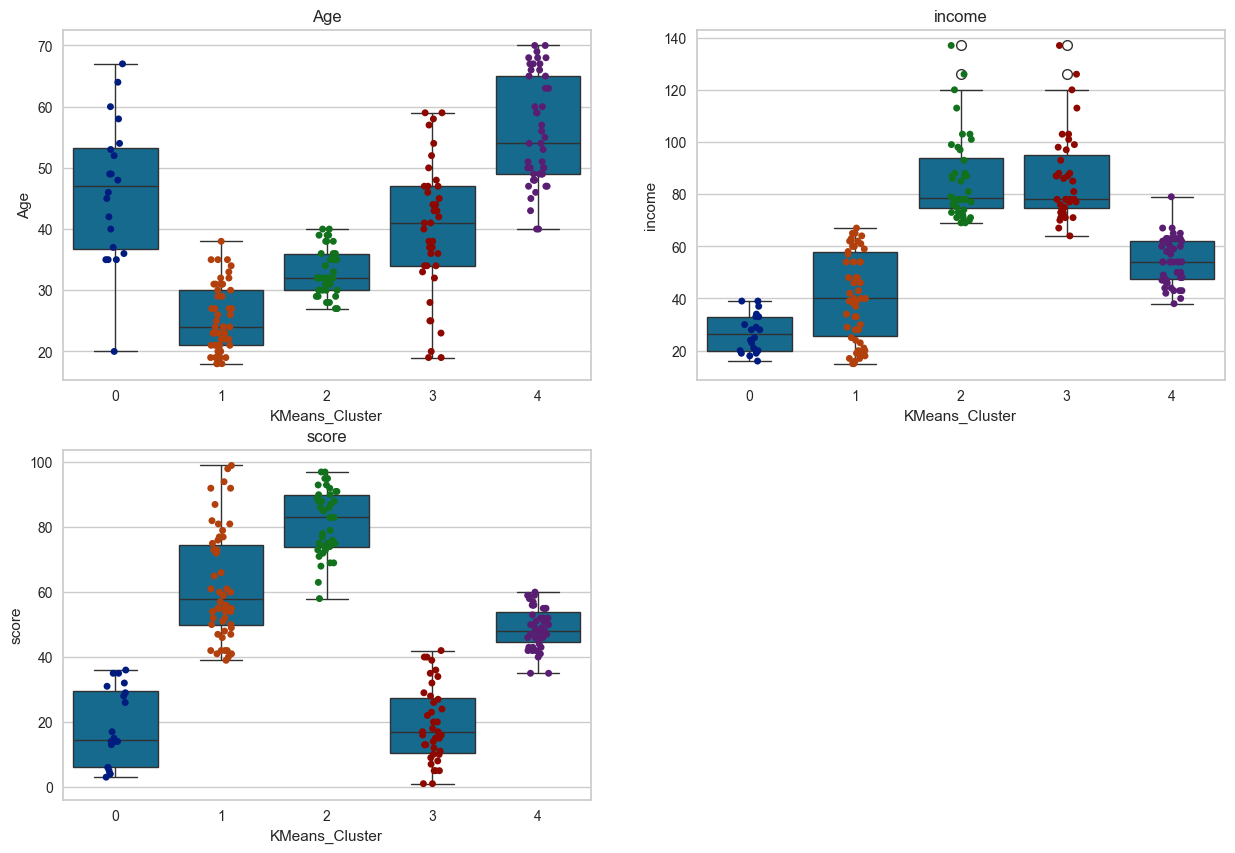

In [29]:
numeric_columns = df.drop(['KMeans_Cluster', 'CustomerID'], axis=1).select_dtypes(include='number').columns

num_plots = len(numeric_columns)
num_cols = 2

num_rows = (num_plots + num_cols - 1) // num_cols
plt.figure(figsize=(15, num_rows * 5))

for i, feature in enumerate(numeric_columns):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.boxplot(y=feature, x="KMeans_Cluster", data=df)
    sns.stripplot(y=feature, x="KMeans_Cluster", data=df, palette="dark", size=5)
    plt.title(feature)

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    <ul style="color: black; font-weight: bold;">
        <li>In Cluster 0, individuals are observed to have moderate to low ages, moderate incomes, and moderate scores. Encouraging increased spending for this cluster could be beneficial.</li>
        <li>Cluster 1 comprises individuals with moderate ages, low to moderate incomes, and the highest scores. Despite their high spending, it may be noted that the revenue generated by this cluster is relatively low.</li>
        <li>Cluster 2 consists of individuals with moderate ages, low to moderate incomes, and the lowest scores. Campaigns targeting this cluster could potentially increase their spending.</li>
        <li>In Cluster 3, individuals are of moderate to older ages, with moderate incomes and scores. Various campaigns could be designed to boost spending for this group.</li>
    </ul>
</div>

<Figure size 2000x1000 with 0 Axes>

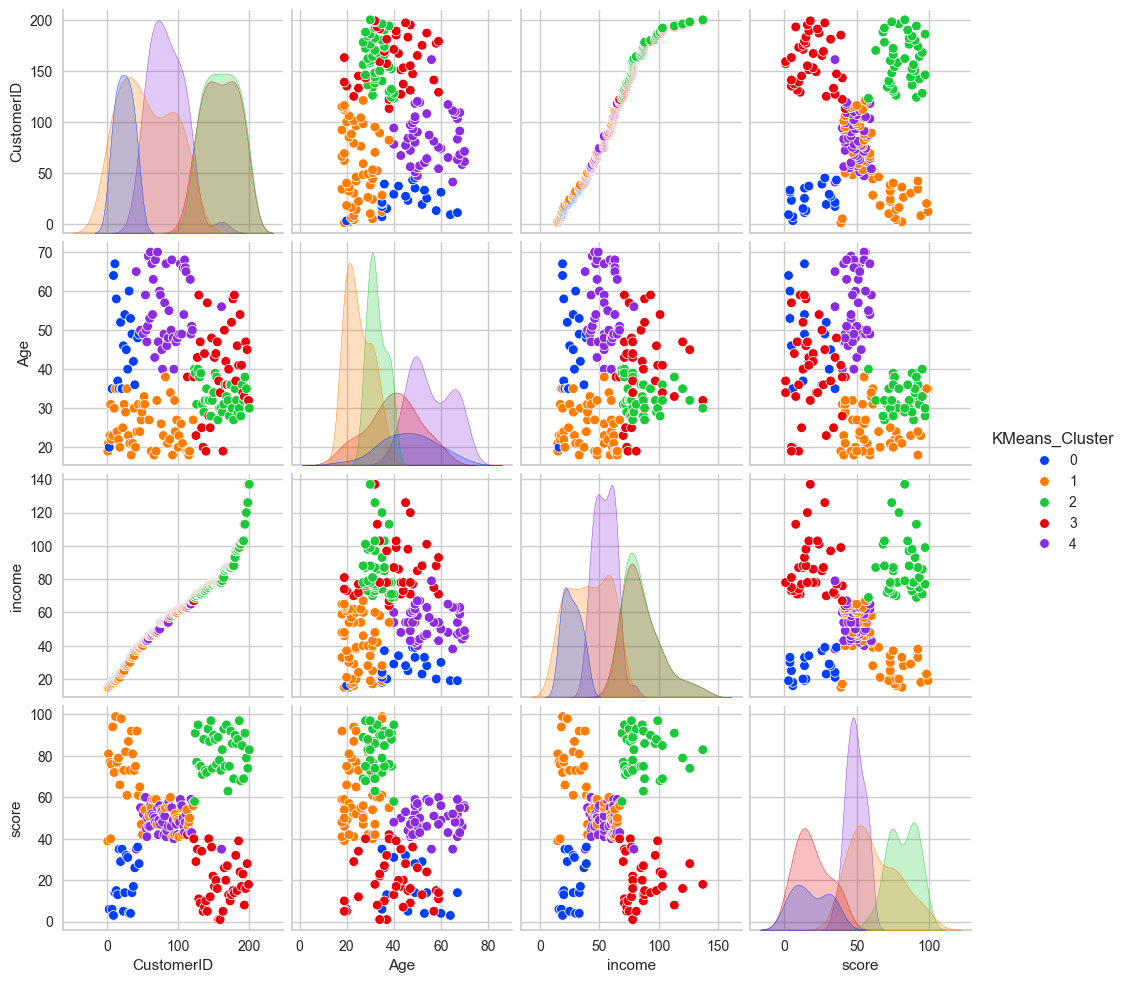

In [31]:
plt.figure(figsize=(20,10))
sns.pairplot(data=df, hue="KMeans_Cluster", palette="bright")

In [34]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'income', 'score', 'KMeans_Cluster'], dtype='object')

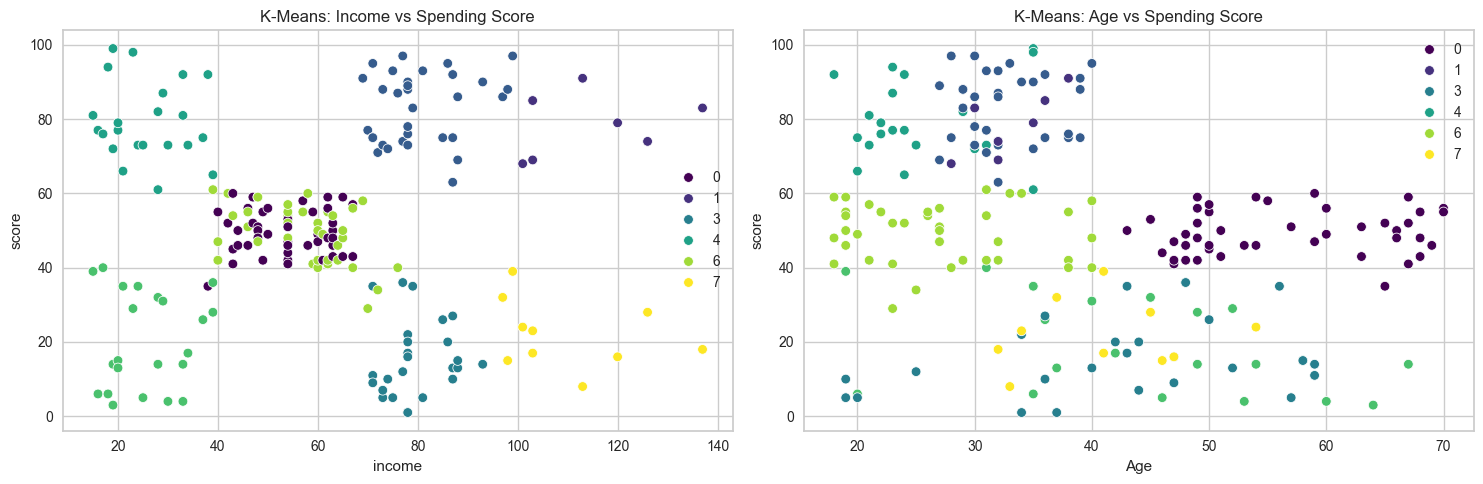

In [37]:
# Visualize K-Means clusters
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='income', y='score', 
                hue=kmeans.labels_, palette='viridis')
plt.title('K-Means: Income vs Spending Score')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Age', y='score', 
                hue=kmeans.labels_, palette='viridis')
plt.title('K-Means: Age vs Spending Score')

plt.tight_layout()
plt.show()

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    <ul style="color: black; font-weight: bold;">
        <li>Considering the smoother distribution in K-means, it is more appropriate to use K-means in this context.</li>
       
</ul>
</div>


<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">✨ DBSCAN clusters ✨</p>
</div>

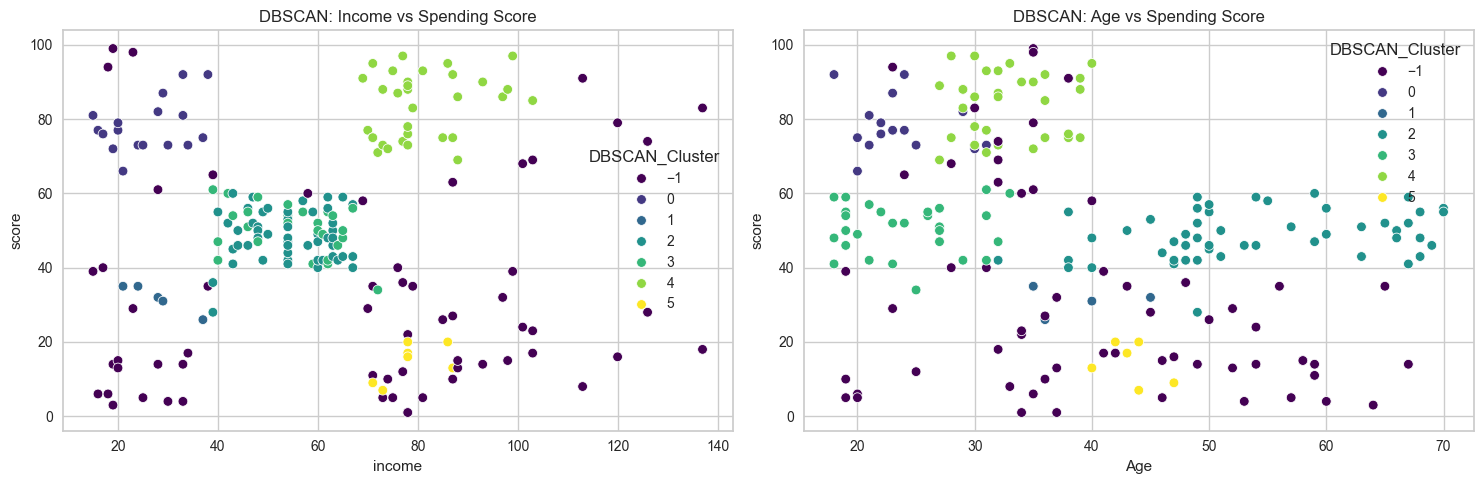

In [38]:
# Based on the k-distance graph, let's choose eps=0.5 and min_samples=5
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Add DBSCAN cluster labels to the dataframe
df['DBSCAN_Cluster'] = dbscan_labels

# Visualize DBSCAN clusters
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='income', y='score', 
                hue='DBSCAN_Cluster', palette='viridis')
plt.title('DBSCAN: Income vs Spending Score')



plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='Age', y='score', 
                hue='DBSCAN_Cluster', palette='viridis')
plt.title('DBSCAN: Age vs Spending Score')

plt.tight_layout()
plt.show()

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">✨ Compare Kmeans & DBSCAN clusters ✨</p>
</div>

c:\Users\Amir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



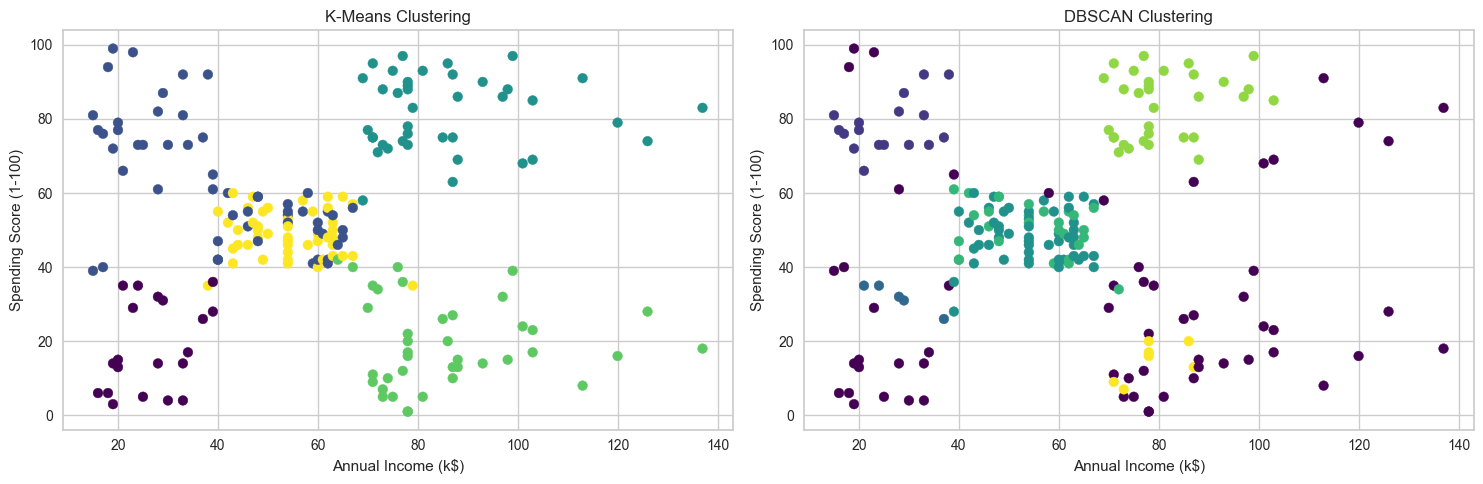

In [39]:
# Data preprocessing - explicitly convert to NumPy array
X = df[['Age', 'income', 'score']].values

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means Clustering
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# DBSCAN Clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Visualization
plt.figure(figsize=(15, 5))

# K-Means visualization - using the original unscaled data for plotting
plt.subplot(1, 2, 1)
plt.scatter(X[:, 1], X[:, 2], c=kmeans_labels, cmap='viridis')  # Annual Income (1) vs Spending Score (2)
plt.title('K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

# DBSCAN visualization
plt.subplot(1, 2, 2)
plt.scatter(X[:, 1], X[:, 2], c=dbscan_labels, cmap='viridis')
plt.title('DBSCAN Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

<a id="1"></a>
# <p style="background: linear-gradient(to right,white,green);color: transparent;font-family: Gabriola;color: navy;font-size: 80%;text-align: center;border-radius: 10px 70px">✨ Conclusion✨</p>
</div>

<div style="border-radius: 5px;
     -webkit-border-radius: 5px;
     -moz-border-radius: 5px;
     font-family: cursive;
     border: 3px solid #007A33;
     background: #F6FFF9;
     color: black;
     font-size: 14px;
     padding: 15px;">
    <ul style="color: black; font-weight: bold;">
        li><strong>Age-Spending-Score:</strong> K-means clustering with 4 clusters provided effective segmentation.</li>
        <li><strong>Income-Spending-Score:</strong> Hierarchical clustering with 5 clusters demonstrated successful results.</li>
        <li><strong>Cluster Distributions:</strong> Some graphs, such as gender-based cluster distributions, exhibited similarities.</li>
        <li><strong>Graph Variances:</strong> Differences were observed in other graphs, emphasizing the need for tailored interpretations.</li>
        <li><strong>Cluster Analysis:</strong> Box plots and bar plots of clusters were scrutinized to convey insights.</li>
        <li><strong>Cluster Selection:</strong> The choice of the number of clusters depends on the nature of the problem, expert opinions, and interpretability.</li>
       
</ul>
</div>